In [ ]:
#Dataset 2
from scipy.io import arff
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

#load the ARFF file
data, meta = arff.loadarff('TimeBasedFeatures-Dataset-15s-VPN.arff')

df = pd.DataFrame(data)
# Drop rows with missing values
df.dropna(inplace=True)
# Drop rows with NaN or infinite values
df = df.replace([np.inf, -np.inf], np.nan).dropna()
df.drop(['class1'], axis=1, inplace=True)

print(df.describe()) #to summarize statistics
print(df.info()) #to print info about dataset

train, test = train_test_split(df, test_size=0.2, shuffle=True)

           duration    total_fiat    total_biat      min_fiat      min_biat  \
count  1.875800e+04  1.875800e+04  1.875800e+04  1.875800e+04  1.875800e+04   
mean   9.791705e+06  6.086783e+05  6.267802e+05  3.314204e+06  2.861716e+06   
std    1.438458e+07  2.243195e+06  2.326442e+06  1.062115e+07  9.652561e+06   
min    0.000000e+00 -1.000000e+00 -1.000000e+00 -1.000000e+00 -1.000000e+00   
25%    3.346690e+05  7.000000e+00  2.000000e+00  2.597050e+04  2.454225e+04   
50%    1.109263e+07  6.200000e+01  2.100000e+01  2.821430e+05  2.865800e+05   
75%    1.494537e+07  1.645000e+03  1.651000e+03  4.289454e+06  4.265465e+06   
max    6.014050e+08  3.768079e+07  4.300238e+07  3.035957e+08  6.001097e+08   

           max_fiat      max_biat     mean_fiat     mean_biat  \
count  1.875800e+04  1.875800e+04  1.875800e+04  1.875800e+04   
mean   1.003929e+06  9.218250e+05  8.448286e+05  6.133578e+05   
std    3.141855e+06  2.495984e+06  4.336559e+06  2.516395e+06   
min    0.000000e+00  0.00000

In [ ]:
#Dataset 2 Binary Naive Bayes CLASSIFIER Minibatch K-Means
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold
from itertools import product
import numpy as np
from sklearn.cluster import MiniBatchKMeans

k = 2
batch_size = 100
max_iter = 100

minibatch_kmeans = MiniBatchKMeans(n_clusters=k, batch_size=batch_size, max_iter=max_iter)

priors_list = [None,[0.5, 0.5], [0.7, 0.3], [0.3, 0.7]]
var_smoothing_list = [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]

num_folds = 5
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)

best_accuracy = 0
best_params = {}

a = 0
for priors, var_smoothing in product(priors_list, var_smoothing_list):
    a += 1
    print(a)

    nb_classifier = GaussianNB(priors=priors, var_smoothing=var_smoothing)
    fold_accuracies = []

    for train_index, test_index in kf.split(train):
        train_labels = minibatch_kmeans.fit_predict(train.iloc[train_index])
        test_labels = minibatch_kmeans.predict(train.iloc[test_index])
        predictions = nb_classifier.predict(train.iloc[test_index])
        fold_accuracy = accuracy_score(test_labels, predictions)
        fold_accuracies.append(fold_accuracy)

    mean_accuracy = np.mean(fold_accuracies)


    if mean_accuracy > best_accuracy:
        best_accuracy = mean_accuracy
        best_params = {'priors': priors, 'var_smoothing': var_smoothing}

print("Best hyperparameters:", best_params)
print("Best accuracy:", best_accuracy)


1


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: 

2


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: 

3


...

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: 

18
19


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: 

20
Best hyperparameters: {'priors': [0.5, 0.5], 'var_smoothing': 1e-05}
Best accuracy: 0.9688114399353003


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


Accuracy of Naive Bayes Classifier with Minibatch K-means cluster labels: 0.9618869936034116
Precision: 0.9642644758916495
Recall: 0.9618869936034116
F1-score: 0.9622168378229261
Confusion Matrix:
 [[1288   17]
 [ 126 2321]]


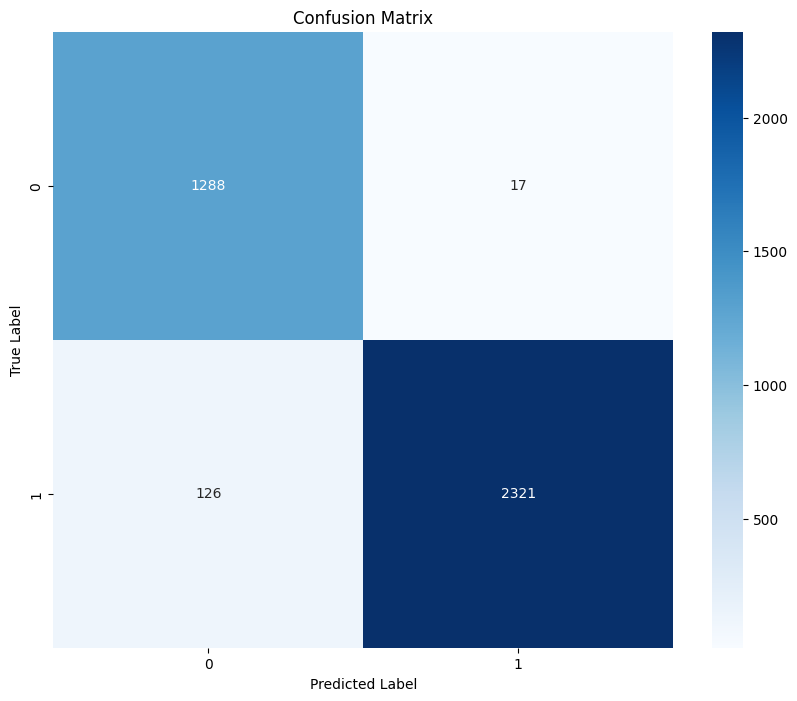

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score
import numpy as np
from sklearn.linear_model import LogisticRegression

k = 2
batch_size = 100
max_iter = 100

minibatch_kmeans = MiniBatchKMeans(n_clusters=k, batch_size=batch_size, max_iter=max_iter)

train_labels = minibatch_kmeans.fit_predict(train)
test_labels = minibatch_kmeans.predict(test)


priors=[0.5, 0.5]
var_smoothing=1e-05
nb_classifier = GaussianNB(priors=priors, var_smoothing=var_smoothing)
nb_classifier.fit(train, train_labels)

predictions = nb_classifier.predict(test)

accuracy = accuracy_score(test_labels, predictions)
precision = precision_score(test_labels, predictions, average='weighted')
recall = recall_score(test_labels, predictions, average='weighted')
f1 = f1_score(test_labels, predictions, average='weighted')
conf_matrix = confusion_matrix(test_labels, predictions)

print("Accuracy of Naive Bayes Classifier with Minibatch K-means cluster labels:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("Confusion Matrix:\n", conf_matrix)
class_labels = np.unique(np.concatenate((test_labels, predictions)))


plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, cmap="Blues", fmt="d", xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
#Dataset 2 Binary Naive Bayes CLASSIFIER GMM
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold
from itertools import product
import numpy as np
from sklearn.mixture import GaussianMixture

n_components=2
covariance_type='tied'

gmm = GaussianMixture(n_components=n_components, covariance_type=covariance_type, reg_covar=0.1, random_state=42)


priors_list = [None,[0.5, 0.5], [0.7, 0.3], [0.3, 0.7]]
var_smoothing_list = [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]


num_folds = 5
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)

best_accuracy = 0
best_params = {}


a = 0
for priors, var_smoothing in product(priors_list, var_smoothing_list):
    a += 1
    print(a)

    nb_classifier = GaussianNB(priors=priors, var_smoothing=var_smoothing)
    fold_accuracies = []

    for train_index, test_index in kf.split(train):
        train_labels = gmm.fit_predict(train.iloc[train_index])
        test_labels = gmm.predict(train.iloc[test_index])
        nb_classifier.fit(train.iloc[train_index], train_labels)
        predictions = nb_classifier.predict(train.iloc[test_index])
        fold_accuracy = accuracy_score(test_labels, predictions)
        fold_accuracies.append(fold_accuracy)

    mean_accuracy = np.mean(fold_accuracies)

    if mean_accuracy > best_accuracy:
        best_accuracy = mean_accuracy
        best_params = {'priors': priors, 'var_smoothing': var_smoothing}
print("Best hyperparameters:", best_params)
print("Best accuracy:", best_accuracy)


1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
Best hyperparameters: {'priors': None, 'var_smoothing': 1e-05}
Best accuracy: 0.9916027990669777


Accuracy of Naive Bayes Classifier with Minibatch GMM cluster labels: 0.9874733475479744
Precision: 0.9947418989707547
Recall: 0.9874733475479744
F1-score: 0.9899933019378688
Confusion Matrix:
 [[3671   47]
 [   0   34]]


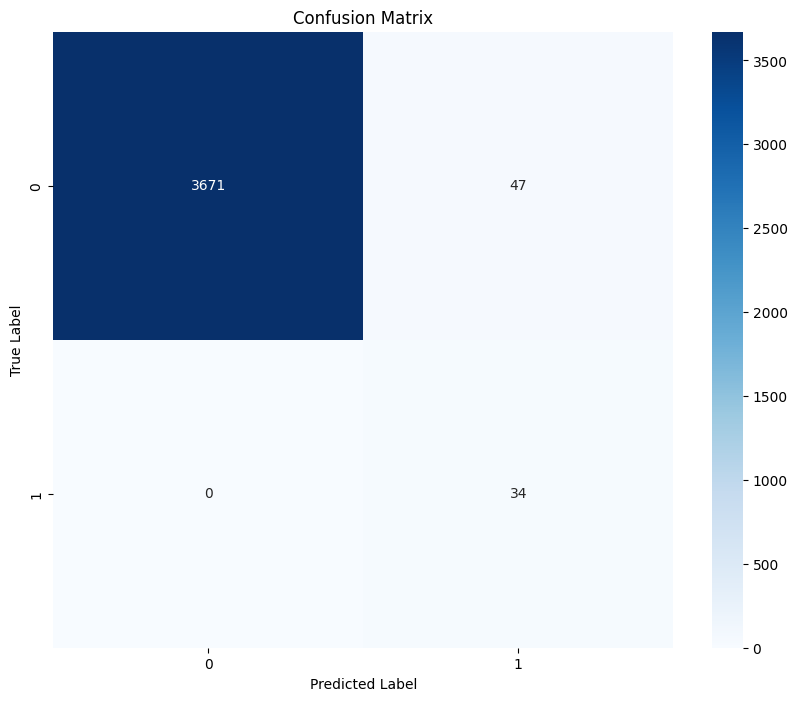

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score
import numpy as np
from sklearn.linear_model import LogisticRegression


n_components=2
covariance_type='tied'

gmm = GaussianMixture(n_components=n_components, covariance_type=covariance_type, reg_covar=0.1, random_state=42)

train_labels = gmm.fit_predict(train)
test_labels =gmm.predict(test)


priors=None
var_smoothing=1e-05
nb_classifier = GaussianNB(priors=priors, var_smoothing=var_smoothing)

nb_classifier.fit(train, train_labels)

predictions = nb_classifier.predict(test)

accuracy = accuracy_score(test_labels, predictions)
precision = precision_score(test_labels, predictions, average='weighted')
recall = recall_score(test_labels, predictions, average='weighted')
f1 = f1_score(test_labels, predictions, average='weighted')
conf_matrix = confusion_matrix(test_labels, predictions)

print("Accuracy of Naive Bayes Classifier with Minibatch GMM cluster labels:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("Confusion Matrix:\n", conf_matrix)
class_labels = np.unique(np.concatenate((test_labels, predictions)))

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, cmap="Blues", fmt="d", xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
#Dataset 2 Binary Naive Bayes CLASSIFIER K-Means
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold
from itertools import product
import numpy as np
from sklearn.mixture import GaussianMixture

k = 2
init_type = 'random'
max_iter = 200

kmeans = KMeans(n_clusters=k, random_state=42, max_iter=max_iter, init=init_type)

priors_list = [None,[0.5, 0.5], [0.7, 0.3], [0.3, 0.7]]
var_smoothing_list = [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]
num_folds = 5
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)

best_accuracy = 0
best_params = {}

a = 0
for priors, var_smoothing in product(priors_list, var_smoothing_list):
    a += 1
    print(a)
    nb_classifier = GaussianNB(priors=priors, var_smoothing=var_smoothing)
    fold_accuracies = []

    for train_index, test_index in kf.split(train):
        train_labels = kmeans.fit_predict(train.iloc[train_index])
        test_labels = kmeans.predict(train.iloc[test_index])
        nb_classifier.fit(train.iloc[train_index], train_labels)
        predictions = nb_classifier.predict(train.iloc[test_index])
        fold_accuracy = accuracy_score(test_labels, predictions)
        fold_accuracies.append(fold_accuracy)

    mean_accuracy = np.mean(fold_accuracies)

    if mean_accuracy > best_accuracy:
        best_accuracy = mean_accuracy
        best_params = {'priors': priors, 'var_smoothing': var_smoothing}
print("Best hyperparameters:", best_params)
print("Best accuracy:", best_accuracy)


1


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:8

2


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:8

3


...

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:8

20


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


Best hyperparameters: {'priors': None, 'var_smoothing': 1e-05}
Best accuracy: 0.9881380867714314


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


Accuracy of Naive Bayes Classifier with K-means cluster labels: 0.9858742004264393
Precision: 0.9944795725804475
Recall: 0.9858742004264393
F1-score: 0.9889171651637626
Confusion Matrix:
 [[  34    0]
 [  53 3665]]


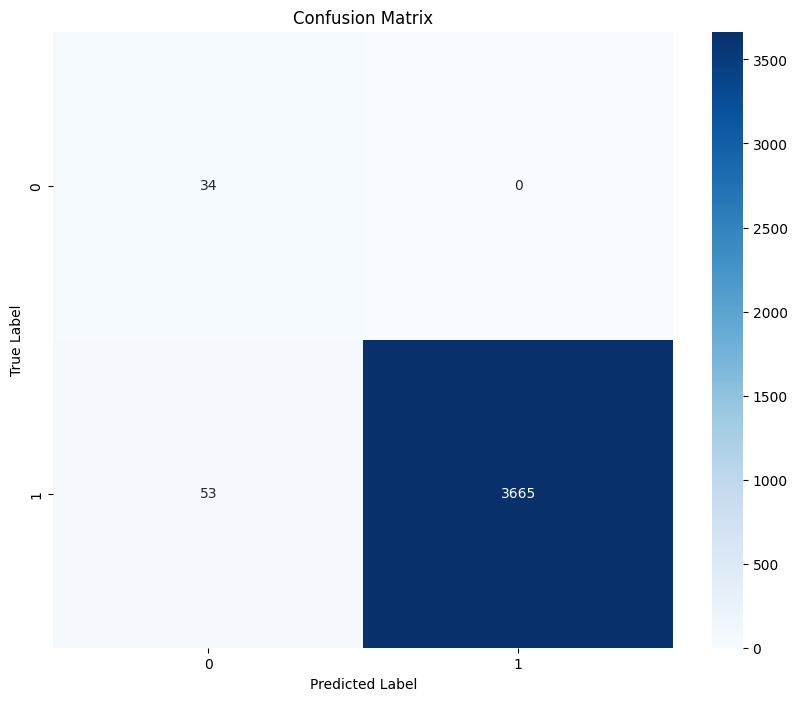

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score
import numpy as np
from sklearn.linear_model import LogisticRegression

k = 2
init_type = 'random'
max_iter = 200

kmeans = KMeans(n_clusters=k, random_state=42, max_iter=max_iter, init=init_type)

train_labels = kmeans.fit_predict(train)
test_labels = kmeans.predict(test)

priors=None
var_smoothing=1e-05
nb_classifier = GaussianNB(priors=priors, var_smoothing=var_smoothing)


nb_classifier.fit(train, train_labels)

predictions = nb_classifier.predict(test)

accuracy = accuracy_score(test_labels, predictions)
precision = precision_score(test_labels, predictions, average='weighted')
recall = recall_score(test_labels, predictions, average='weighted')
f1 = f1_score(test_labels, predictions, average='weighted')
conf_matrix = confusion_matrix(test_labels, predictions)

print("Accuracy of Naive Bayes Classifier with K-means cluster labels:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("Confusion Matrix:\n", conf_matrix)
class_labels = np.unique(np.concatenate((test_labels, predictions)))

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, cmap="Blues", fmt="d", xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
#Dataset 2 Binary SVM CLASSIFIER Minibatch K-Means
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold
from itertools import product
import numpy as np
from sklearn.cluster import MiniBatchKMeans

k = 2
batch_size = 100
max_iter = 100

minibatch_kmeans = MiniBatchKMeans(n_clusters=k, batch_size=batch_size, max_iter=max_iter)

priors_list = [None,[0.5, 0.5], [0.7, 0.3], [0.3, 0.7]]
C_values = [0.001, 0.01, 0.1, 1, 10]

num_folds = 5
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)

best_accuracy = 0
best_params = {}

a = 0
for priors, C in product(priors_list, C_values):
    a += 1
    print(a)
    class_weights = 'balanced' if priors is None else {i: priors[i] for i in range(len(priors))}
    svm_classifier = SVC(C=C, kernel='linear', class_weight=class_weights)
    fold_accuracies = []

        train_labels = minibatch_kmeans.fit_predict(train.iloc[train_index])
        test_labels = minibatch_kmeans.predict(train.iloc[test_index])
        svm_classifier.fit(train.iloc[train_index], train_labels)
        predictions = svm_classifier.predict(train.iloc[test_index])
        fold_accuracy = accuracy_score(test_labels, predictions)
        fold_accuracies.append(fold_accuracy)

    mean_accuracy = np.mean(fold_accuracies)

    if mean_accuracy > best_accuracy:
        best_accuracy = mean_accuracy
        best_params = {'priors': priors, 'C': C}

print("Best hyperparameters:", best_params)
print("Best accuracy:", best_accuracy)


1


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: 

2


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: 

3


...

19


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


20


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: 

Best hyperparameters: {'priors': [0.3, 0.7], 'C': 1}
Best accuracy: 0.9998000888444691


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


Accuracy of SVM Classifier with Minibatch K-means cluster labels: 1.0
Precision: 1.0
Recall: 1.0
F1-score: 1.0
Confusion Matrix:
 [[3718    0]
 [   0   34]]


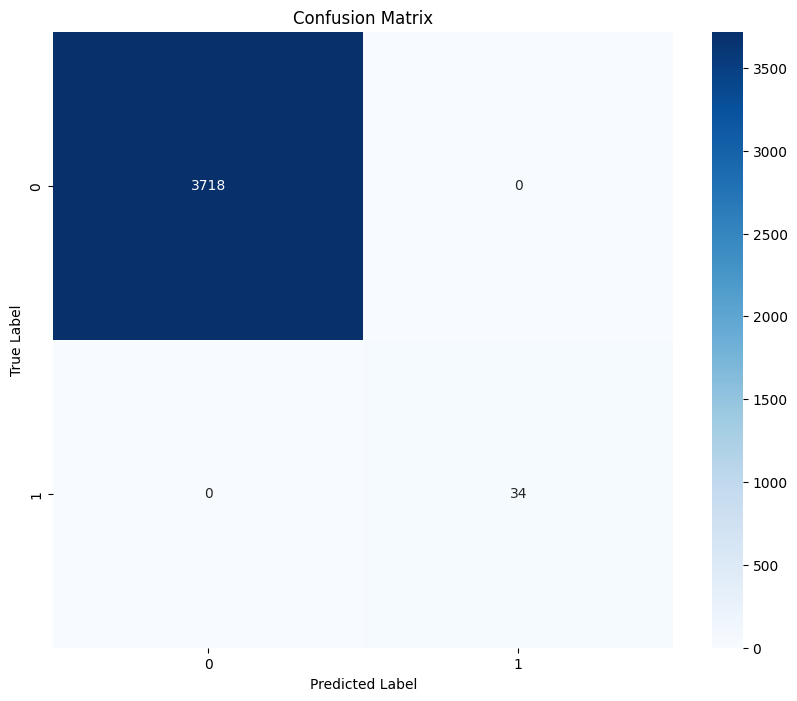

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score
import numpy as np
from sklearn.linear_model import LogisticRegression

k = 2
batch_size = 100
max_iter = 100

minibatch_kmeans = MiniBatchKMeans(n_clusters=k, batch_size=batch_size, max_iter=max_iter)

train_labels = minibatch_kmeans.fit_predict(train)
test_labels = minibatch_kmeans.predict(test)

C=1
priors=[0.3, 0.7]

class_weights = 'balanced' if priors is None else {i: priors[i] for i in range(len(priors))}
svm_classifier = SVC(C=C, kernel='linear', class_weight=class_weights)
svm_classifier.fit(train, train_labels)

predictions = svm_classifier.predict(test)

accuracy = accuracy_score(test_labels, predictions)
precision = precision_score(test_labels, predictions, average='weighted')
recall = recall_score(test_labels, predictions, average='weighted')
f1 = f1_score(test_labels, predictions, average='weighted')
conf_matrix = confusion_matrix(test_labels, predictions)

print("Accuracy of SVM Classifier with Minibatch K-means cluster labels:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("Confusion Matrix:\n", conf_matrix)
class_labels = np.unique(np.concatenate((test_labels, predictions)))

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, cmap="Blues", fmt="d", xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
#CALISTIRAMADIM
#Dataset 2 Binary Naive Bayes CLASSIFIER GMM
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold
from itertools import product
import numpy as np
from sklearn.cluster import MiniBatchKMeans
from sklearn.mixture import GaussianMixture

n_components=2
covariance_type='tied'

gmm = GaussianMixture(n_components=n_components, covariance_type=covariance_type, reg_covar=0.1, random_state=42)

priors_list = [0.3, 0.7]
C_values = [0.001, 0.01, 0.1, 1, 10]

num_folds = 5
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)

best_accuracy = 0
best_params = {}

a = 0
for priors, C in product(priors_list, C_values):
    a += 1
    print(a)

    class_weights = 'balanced' if priors is None else {i: priors[i] for i in range(len(priors_list))}
    svm_classifier = SVC(C=C, kernel='linear', class_weight=class_weights)
    fold_accuracies = []

    for train_index, test_index in kf.split(train):
        train_labels = gmm.fit_predict(train.iloc[train_index])
        test_labels = gmm.predict(train.iloc[test_index])
        svm_classifier.fit(train.iloc[train_index], train_labels)
        predictions = svm_classifier.predict(train.iloc[test_index])
        fold_accuracy = accuracy_score(test_labels, predictions)
        fold_accuracies.append(fold_accuracy)


    mean_accuracy = np.mean(fold_accuracies)
    if mean_accuracy > best_accuracy:
        best_accuracy = mean_accuracy
        best_params = {'priors': priors, 'C': C}
print("Best hyperparameters:", best_params)
print("Best accuracy:", best_accuracy)


1


TypeError: 'float' object is not subscriptable

In [ ]:
#Dataset 2 Binary Naive Bayes CLASSIFIER K-Means
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold
from itertools import product
import numpy as np
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

k = 2
init_type = 'random'
max_iter = 200

kmeans = KMeans(n_clusters=k, random_state=42, max_iter=max_iter, init=init_type)

priors_list = [0.3, 0.7]
C_values = [0.001, 0.01, 0.1, 1, 10]

num_folds = 5
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)

best_accuracy = 0
best_params = {}

a = 0
for priors, C in product(priors_list, C_values):
    a += 1
    print(a)

    class_weights = 'balanced' if priors is None else {i: priors[i] for i in range(len(priors))}
    svm_classifier = SVC(C=C, kernel='linear', class_weight=class_weights)
    fold_accuracies = []

    for train_index, test_index in kf.split(train):

        train_labels = kmeans.fit_predict(train.iloc[train_index])
        test_labels = kmeans.predict(train.iloc[test_index])
        svm_classifier.fit(train.iloc[train_index], train_labels)
        predictions = svm_classifier.predict(train.iloc[test_index])
        fold_accuracy = accuracy_score(test_labels, predictions)
        fold_accuracies.append(fold_accuracy)

    mean_accuracy = np.mean(fold_accuracies)

    if mean_accuracy > best_accuracy:
        best_accuracy = mean_accuracy
        best_params = {'priors': priors, 'C': C}

print("Best hyperparameters:", best_params)
print("Best accuracy:", best_accuracy)


1


TypeError: object of type 'float' has no len()

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


Accuracy of SVM Classifier with K-means cluster labels: 0.9976012793176973
Precision: 0.9976276067398201
Recall: 0.9976012793176973
F1-score: 0.997604171366084
Confusion Matrix:
 [[2902    0    0    8]
 [   0   29    0    1]
 [   0    0    1    0]
 [   0    0    0  811]]


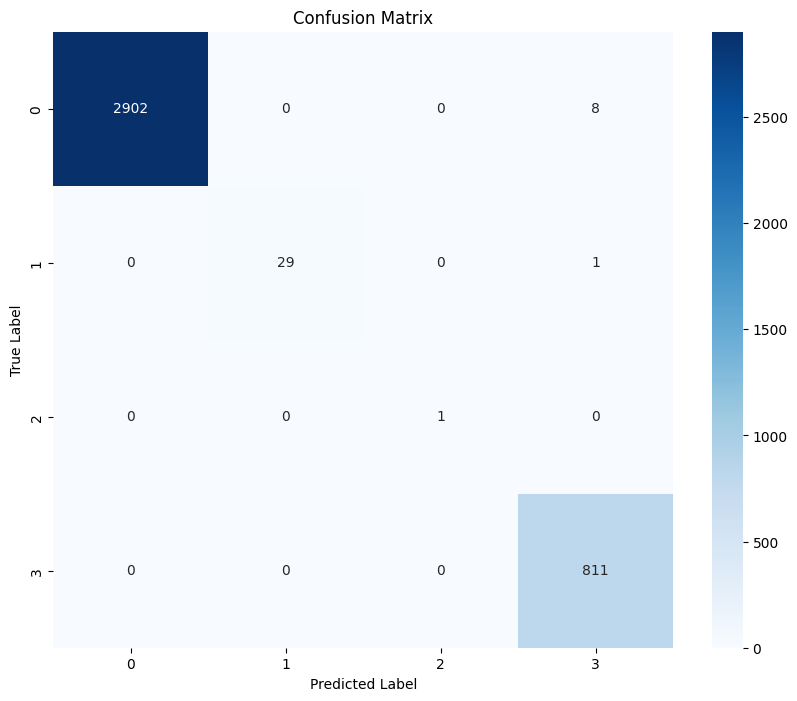

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score
import numpy as np
from sklearn.linear_model import LogisticRegression

k = 2
init_type = 'random'
max_iter = 200


kmeans = KMeans(n_clusters=k, random_state=42, max_iter=max_iter, init=init_type)

train_labels = kmeans.fit_predict(train)
test_labels = kmeans.predict(test)

C=0.001
priors=None

class_weights = 'balanced' if priors is None else {i: priors[i] for i in range(len(priors))}
svm_classifier = SVC(C=C, kernel='linear', class_weight=class_weights)

svm_classifier.fit(train, train_labels)
predictions = svm_classifier.predict(test)

accuracy = accuracy_score(test_labels, predictions)
precision = precision_score(test_labels, predictions, average='weighted')
recall = recall_score(test_labels, predictions, average='weighted')
f1 = f1_score(test_labels, predictions, average='weighted')
conf_matrix = confusion_matrix(test_labels, predictions)

print("Accuracy of SVM Classifier with K-means cluster labels:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("Confusion Matrix:\n", conf_matrix)

class_labels = np.unique(np.concatenate((test_labels, predictions)))
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, cmap="Blues", fmt="d", xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
#Dataset 2 Binary XGBOOST CLASSIFIER Minibatch K-Means
import xgboost as xgb
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import accuracy_score
from sklearn.cluster import MiniBatchKMeans
from itertools import product
import numpy as np

k = 2
batch_size = 100
max_iter = 100
minibatch_kmeans = MiniBatchKMeans(n_clusters=k, batch_size=batch_size, max_iter=max_iter)

param_grid = {
    'max_depth': [3, 6],
    'learning_rate': [0.01, 0.1],
    'n_estimators': [100, 300],
    'gamma': [0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
}

num_folds = 5
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)

best_accuracy = 0
best_params = {}

a = 0
for params in product(*param_grid.values()):
    a += 1
    print(a)

    max_depth, learning_rate, n_estimators, gamma, subsample, colsample_bytree = params

    xgb_classifier = xgb.XGBClassifier(max_depth=max_depth, learning_rate=learning_rate,
                                       n_estimators=n_estimators, gamma=gamma,
                                       subsample=subsample, colsample_bytree=colsample_bytree,
                                       random_state=42)
    fold_accuracies = []

    for train_index, test_index in kf.split(train):

        train_labels = minibatch_kmeans.fit_predict(train.iloc[train_index])
        test_labels = minibatch_kmeans.predict(train.iloc[test_index])
        xgb_classifier.fit(train.iloc[train_index], train_labels)
        predictions = xgb_classifier.predict(train.iloc[test_index])
        fold_accuracy = accuracy_score(test_labels, predictions)
        fold_accuracies.append(fold_accuracy)

    mean_accuracy = np.mean(fold_accuracies)

    if mean_accuracy > best_accuracy:
        best_accuracy = mean_accuracy
        best_params = {'max_depth': max_depth, 'learning_rate': learning_rate,
                       'n_estimators': n_estimators, 'gamma': gamma,
                       'subsample': subsample, 'colsample_bytree': colsample_bytree}

print("Best hyperparameters:", best_params)
print("Best accuracy:", best_accuracy)


1


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: 

2


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: 

3


...

63


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: 

64


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: 

Best hyperparameters: {'max_depth': 6, 'learning_rate': 0.1, 'n_estimators': 300, 'gamma': 0.1, 'subsample': 1.0, 'colsample_bytree': 0.8}
Best accuracy: 0.9992002887778246


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


Accuracy of XGBoost Classifier with Minibatch K-means cluster labels: 0.9981343283582089
Precision: 0.998143966514292
Recall: 0.9981343283582089
F1-score: 0.9981353840350318
Confusion Matrix:
 [[1348    0]
 [   7 2397]]


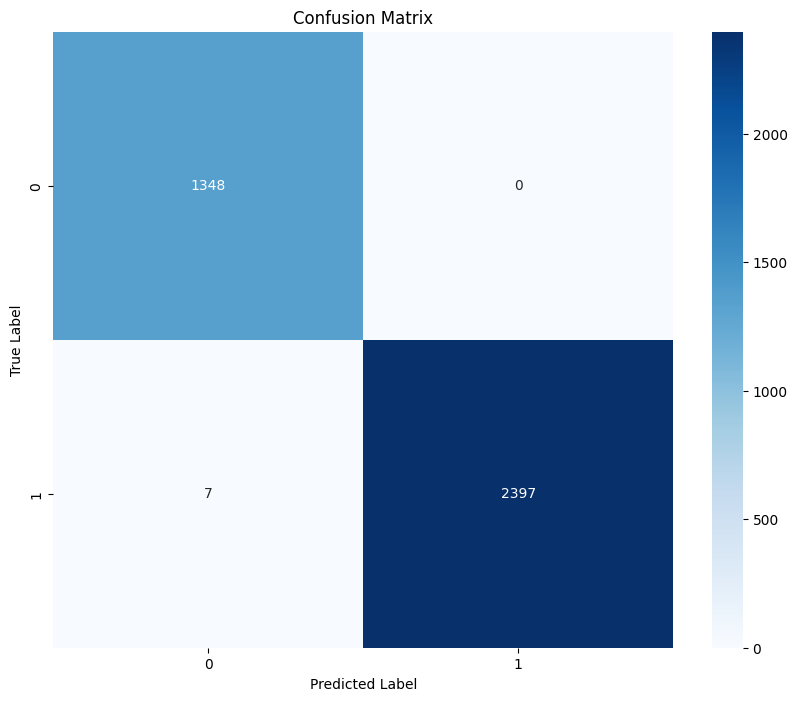

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import xgboost as xgb
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import MiniBatchKMeans

k = 2
batch_size = 100
max_iter = 100

minibatch_kmeans = MiniBatchKMeans(n_clusters=k, batch_size=batch_size, max_iter=max_iter)

train_labels = minibatch_kmeans.fit_predict(train)
test_labels = minibatch_kmeans.predict(test)

max_depth=6
learning_rate=0.1
n_estimators=300
gamma=0.1
subsample= 1.0
colsample_bytree=0.8

xgb_classifier = xgb.XGBClassifier(max_depth=max_depth, learning_rate=learning_rate,
                                       n_estimators=n_estimators, gamma=gamma,
                                       subsample=subsample, colsample_bytree=colsample_bytree,
                                       random_state=42)

xgb_classifier.fit(train, train_labels)
predictions = xgb_classifier.predict(test)

accuracy = accuracy_score(test_labels, predictions)
precision = precision_score(test_labels, predictions, average='weighted')
recall = recall_score(test_labels, predictions, average='weighted')
f1 = f1_score(test_labels, predictions, average='weighted')
conf_matrix = confusion_matrix(test_labels, predictions)

print("Accuracy of XGBoost Classifier with Minibatch K-means cluster labels:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("Confusion Matrix:\n", conf_matrix)
class_labels = np.unique(np.concatenate((test_labels, predictions)))

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, cmap="Blues", fmt="d", xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
#Dataset 2 Binary XGBOOST CLASSIFIER K-Means
import xgboost as xgb
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import accuracy_score
from sklearn.cluster import MiniBatchKMeans
from itertools import product
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans

k = 2
init_type = 'random'
max_iter = 200

kmeans = KMeans(n_clusters=k, random_state=42, max_iter=max_iter, init=init_type)

param_grid = {
    'max_depth': [3, 6],
    'learning_rate': [0.01, 0.1],
    'n_estimators': [100, 300],
    'gamma': [0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
}
num_folds = 5
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)

best_accuracy = 0
best_params = {}


a = 0
for params in product(*param_grid.values()):
    a += 1
    print(a)

    max_depth, learning_rate, n_estimators, gamma, subsample, colsample_bytree = params

    xgb_classifier = xgb.XGBClassifier(max_depth=max_depth, learning_rate=learning_rate,
                                       n_estimators=n_estimators, gamma=gamma,
                                       subsample=subsample, colsample_bytree=colsample_bytree,
                                       random_state=42)
    fold_accuracies = []

    for train_index, test_index in kf.split(train):
        train_labels = kmeans.fit_predict(train.iloc[train_index])
        test_labels = kmeans.predict(train.iloc[test_index])
        xgb_classifier.fit(train.iloc[train_index], train_labels)
        predictions = xgb_classifier.predict(train.iloc[test_index])
        fold_accuracy = accuracy_score(test_labels, predictions)
        fold_accuracies.append(fold_accuracy)
    mean_accuracy = np.mean(fold_accuracies)

    if mean_accuracy > best_accuracy:
        best_accuracy = mean_accuracy
        best_params = {'max_depth': max_depth, 'learning_rate': learning_rate,
                       'n_estimators': n_estimators, 'gamma': gamma,
                       'subsample': subsample, 'colsample_bytree': colsample_bytree}

print("Best hyperparameters:", best_params)
print("Best accuracy:", best_accuracy)


1


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:8

2


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:8

3


...

63


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:8

64


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:8

Best hyperparameters: {'max_depth': 3, 'learning_rate': 0.1, 'n_estimators': 100, 'gamma': 0.1, 'subsample': 0.8, 'colsample_bytree': 1.0}
Best accuracy: 0.9997334443926198


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


Accuracy of XGBoost Classifier with K-means cluster labels: 0.9994669509594882
Precision: 0.9994669509594882
Recall: 0.9994669509594882
F1-score: 0.9994669509594882
Confusion Matrix:
 [[  33    1]
 [   1 3717]]


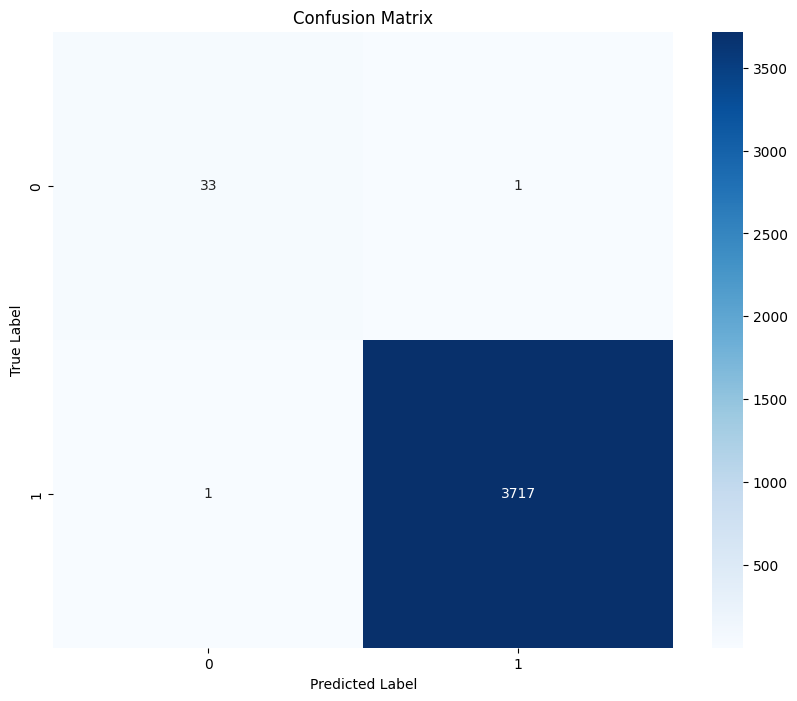

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score
import numpy as np
from sklearn.linear_model import LogisticRegression

k = 2
init_type = 'random'
max_iter = 200

kmeans = KMeans(n_clusters=k, random_state=42, max_iter=max_iter, init=init_type)

train_labels = kmeans.fit_predict(train)
test_labels = kmeans.predict(test)

max_depth=3
learning_rate=0.1
n_estimators=100
gamma=0.1
subsample= 0.8
colsample_bytree=1.0

xgb_classifier = xgb.XGBClassifier(max_depth=max_depth, learning_rate=learning_rate,
                                       n_estimators=n_estimators, gamma=gamma,
                                       subsample=subsample, colsample_bytree=colsample_bytree,
                                       random_state=42)

xgb_classifier.fit(train, train_labels)

predictions = xgb_classifier.predict(test)

accuracy = accuracy_score(test_labels, predictions)
precision = precision_score(test_labels, predictions, average='weighted')
recall = recall_score(test_labels, predictions, average='weighted')
f1 = f1_score(test_labels, predictions, average='weighted')
conf_matrix = confusion_matrix(test_labels, predictions)

print("Accuracy of XGBoost Classifier with K-means cluster labels:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("Confusion Matrix:\n", conf_matrix)

class_labels = np.unique(np.concatenate((test_labels, predictions)))
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, cmap="Blues", fmt="d", xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
#Dataset 2 Binary XGBOOST CLASSIFIER GMM
import xgboost as xgb
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import accuracy_score
from sklearn.cluster import MiniBatchKMeans
from itertools import product
import numpy as np
from sklearn.mixture import GaussianMixture

n_components=2
covariance_type='tied'

gmm = GaussianMixture(n_components=n_components, covariance_type=covariance_type, reg_covar=0.1, random_state=42)

param_grid = {
    'max_depth': [3, 6],
    'learning_rate': [0.01, 0.1],
    'n_estimators': [100, 300],
    'gamma': [0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
}

num_folds = 5
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)

best_accuracy = 0
best_params = {}

a = 0
for params in product(*param_grid.values()):
    a += 1
    print(a)

    max_depth, learning_rate, n_estimators, gamma, subsample, colsample_bytree = params

    xgb_classifier = xgb.XGBClassifier(max_depth=max_depth, learning_rate=learning_rate,
                                       n_estimators=n_estimators, gamma=gamma,
                                       subsample=subsample, colsample_bytree=colsample_bytree,
                                       random_state=42)
    fold_accuracies = []

    for train_index, test_index in kf.split(train):
        train_labels = gmm.fit_predict(train.iloc[train_index])
        test_labels = gmm.predict(train.iloc[test_index])
        xgb_classifier.fit(train.iloc[train_index], train_labels)
        predictions = xgb_classifier.predict(train.iloc[test_index])
        fold_accuracy = accuracy_score(test_labels, predictions)
        fold_accuracies.append(fold_accuracy)

    mean_accuracy = np.mean(fold_accuracies)

    if mean_accuracy > best_accuracy:
        best_accuracy = mean_accuracy
        best_params = {'max_depth': max_depth, 'learning_rate': learning_rate,
                       'n_estimators': n_estimators, 'gamma': gamma,
                       'subsample': subsample, 'colsample_bytree': colsample_bytree}

print("Best hyperparameters:", best_params)
print("Best accuracy:", best_accuracy)


Accuracy of XGBoost Classifier with GMM cluster labels: 0.9994669509594882
Precision: 0.9994669509594882
Recall: 0.9994669509594882
F1-score: 0.9994669509594882
Confusion Matrix:
 [[3717    1]
 [   1   33]]


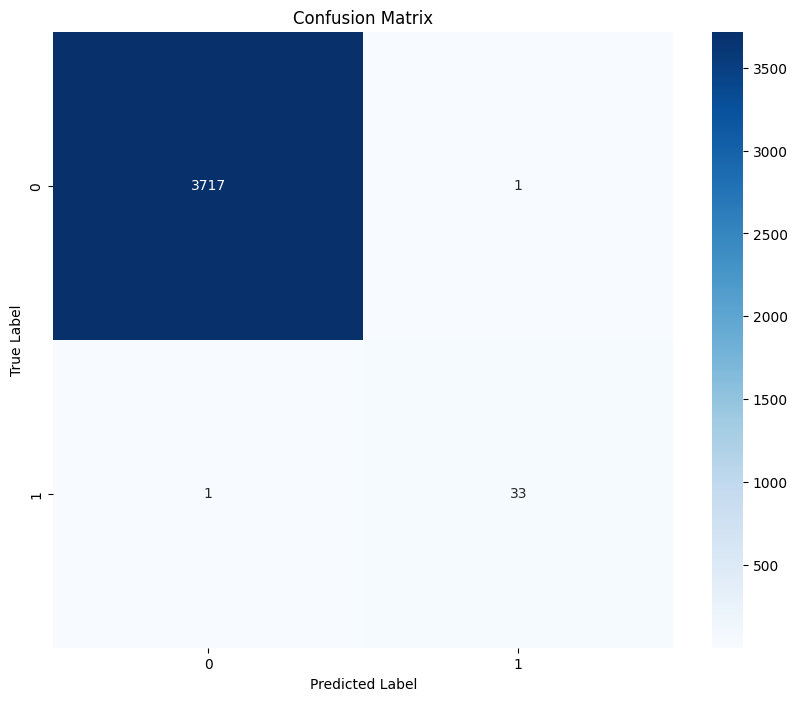

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score
import numpy as np
from sklearn.linear_model import LogisticRegression

n_components=2
covariance_type='tied'

gmm = GaussianMixture(n_components=n_components, covariance_type=covariance_type, reg_covar=0.1, random_state=42)

train_labels = gmm.fit_predict(train)
test_labels = gmm.predict(test)

max_depth=6
learning_rate=0.01
n_estimators=300
gamma=0.1
subsample= 0.8
colsample_bytree=1.0

xgb_classifier = xgb.XGBClassifier(max_depth=max_depth, learning_rate=learning_rate,
                                       n_estimators=n_estimators, gamma=gamma,
                                       subsample=subsample, colsample_bytree=colsample_bytree,
                                       random_state=42)

xgb_classifier.fit(train, train_labels)
predictions = xgb_classifier.predict(test)

accuracy = accuracy_score(test_labels, predictions)
precision = precision_score(test_labels, predictions, average='weighted')
recall = recall_score(test_labels, predictions, average='weighted')
f1 = f1_score(test_labels, predictions, average='weighted')
conf_matrix = confusion_matrix(test_labels, predictions)

print("Accuracy of XGBoost Classifier with GMM cluster labels:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("Confusion Matrix:\n", conf_matrix)
class_labels = np.unique(np.concatenate((test_labels, predictions)))

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, cmap="Blues", fmt="d", xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
import pandas as pd

score_data = {
    'Logistic Regression': [0.96543126],
    'Naive Bayes': [0.96792969],
    'Support Vector Machine': [0.99976244],
    'Decision Tree': [0.9973932],
    'Random Forest': [0.998218],
    'AdaBoost': [0.97132495],
    'XGBoost': [0.9988716],
}

df = pd.DataFrame(score_data)
df = df.transpose()
df.columns = ['Score']

print(df)

                           Score
Logistic Regression     0.965431
Naive Bayes             0.967930
Support Vector Machine  0.999762
Decision Tree           0.997393
Random Forest           0.998218
AdaBoost                0.971325
XGBoost                 0.998872
